<a href="https://colab.research.google.com/github/vrAxiom/PrediCT-CLI/blob/main/colab%20notebooks/10_project1_totalseg_groundtruth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 — Step P1.3: TotalSegmentator heart masks (ground truth)

This notebook:

1. Loads `data/metadata_clean.csv` (validated DICOM series)
2. Selects **all valid subjects**
3. Runs TotalSegmentator **heart-only** segmentation using `--roi_subset heart`
4. Post-processes the mask to fill the middle area (ensuring coronary arteries and calcium are covered)
5. Records inference and processing times and writes a manifest CSV

Reference: TotalSegmentator supports DICOM folder input and `--roi_subset` (see docs)【https://github.com/wasserth/TotalSegmentator】.

Do not hardcode license numbers in this notebook. Set them in Colab Secrets / environment variables.

In [1]:
# Uncomment if running on Colab from google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install TotalSegmentator pandas tqdm nibabel scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 6.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## License activation

Set an environment variable `TOTALSEG_LICENSE` in your environment (Colab Secrets recommended), then run:

`!totalseg_set_license -l "$TOTALSEG_LICENSE"`

If `TOTALSEG_LICENSE` is empty, skip this cell.

In [3]:
import os
import subprocess
from getpass import getpass

# Ask user for license at runtime if not already set
lic = os.environ.get('TOTALSEG_LICENSE', '').strip()
if not lic:
    lic = getpass('Enter your TOTALSEG_LICENSE key (input hidden): ').strip()

if lic:
    os.environ['TOTALSEG_LICENSE'] = lic
    # Use subprocess to pass the key directly — avoids shell env expansion issues
    result = subprocess.run(
        ['totalseg_set_license', '-l', lic],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('License activated successfully.')
        if result.stdout:
            print(result.stdout)
    else:
        print('License activation failed:')
        print(result.stderr or result.stdout)
else:
    print('No license provided; skipping license activation.')

Enter your TOTALSEG_LICENSE key (input hidden): ··········
License activated successfully.
License has been successfully saved.



## Configure paths

Set `PREDICT_RAW_DIR` to your COCA patient folder root.

Example:
`/content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient`

In [5]:
from pathlib import Path
import os
import warnings

# Print current working directory for debugging
print(f"Current working directory: {os.getcwd()}")

# Ask user for PREDICT_RAW_DIR at runtime if not already set
raw_dir_str = os.environ.get('PREDICT_RAW_DIR', '').strip()
if not raw_dir_str:
    raw_dir_str = input(
        'Enter PREDICT_RAW_DIR (path to COCA patient folder root):\n'
        'e.g. /content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient\n> '
    ).strip()
    if raw_dir_str:
        os.environ['PREDICT_RAW_DIR'] = raw_dir_str

raw_dir = Path(raw_dir_str)
assert raw_dir.exists(), f"PREDICT_RAW_DIR missing or invalid: {raw_dir}"

# Derive ROOT from raw_dir for robustness, assuming project root is 3 levels up from 'patient'
# Example: /content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient
# Project ROOT would be /content/drive/MyDrive/GSoC_PrediCT
ROOT = raw_dir.parents[3] # Adjust this index if your project structure differs

metadata_csv = ROOT / 'data' / 'metadata_clean.csv'
if not metadata_csv.exists():
    warnings.warn(
        f"metadata_clean.csv not found at {metadata_csv}. "
        "Run the validate-metadata notebook first before running inference cells."
    )
    print(f"WARNING: {metadata_csv} does not exist yet — run validate-metadata first.")
else:
    print(f"metadata_csv OK: {metadata_csv}")

out_root = ROOT / 'outputs' / 'project1' / 'totalseg_heart'
out_root.mkdir(parents=True, exist_ok=True)

print(f"ROOT      : {ROOT}")
print(f"raw_dir   : {raw_dir}")
print(f"out_root  : {out_root}")
raw_dir, metadata_csv, out_root

Current working directory: /content
Enter PREDICT_RAW_DIR (path to COCA patient folder root):
e.g. /content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient
> /content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient
metadata_csv OK: /content/drive/MyDrive/GSoC_PrediCT/data/metadata_clean.csv
ROOT      : /content/drive/MyDrive/GSoC_PrediCT
raw_dir   : /content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient
out_root  : /content/drive/MyDrive/GSoC_PrediCT/outputs/project1/totalseg_heart


(PosixPath('/content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient'),
 PosixPath('/content/drive/MyDrive/GSoC_PrediCT/data/metadata_clean.csv'),
 PosixPath('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/totalseg_heart'))

## Select all subjects

This selection is saved to `outputs/project1/selected_subjects.txt` for reproducibility.

In [10]:
import pandas as pd
import numpy as np
import random

df = pd.read_csv(metadata_csv)
subject_ids = df['subject_id'].astype(str).tolist()

# Select a random subset of 40 subjects for faster testing
# You can change the number 40 if you want a different sample size (e.g., 30)
selected = random.sample(subject_ids, min(40, len(subject_ids)))

sel_path = Path('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/selected_subjects.txt')
sel_path.parent.mkdir(parents=True, exist_ok=True)
sel_path.write_text('\n'.join(selected) + '\n', encoding='utf-8')

len(selected), selected[:10], sel_path

(40,
 ['185', '374', '554', '761', '372', '586', '413', '159', '464', '29'],
 PosixPath('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/selected_subjects.txt'))

## Run TotalSegmentator (heart only)

Outputs go to:
`outputs/project1/totalseg_heart/<subject_id>/`

A per-subject timing manifest is written to:
`outputs/project1/totalseg_heart_manifest.csv`

In [11]:
import time
import subprocess
import nibabel as nib
import scipy.ndimage as ndimage
from tqdm import tqdm

rows = []
for sid in tqdm(selected, desc='TotalSegmentator', unit='subject'):
    series_dir = raw_dir / str(sid)
    out_dir = out_root / str(sid)
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        'TotalSegmentator',
        '-i', str(series_dir),
        '-o', str(out_dir),
        '--roi_subset', 'heart',
    ]

    t0 = time.perf_counter()
    try:
        subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        ok = True
        err = ''
    except subprocess.CalledProcessError as e:
        ok = False
        err = (e.stdout or '')[-500:]

    ts_time = time.perf_counter() - t0

    # Post-processing: Fill the heart mask to ensure coronary arteries and calcium are covered
    t1 = time.perf_counter()
    fill_ok = False
    if ok:
        mask_path = out_dir / 'heart.nii.gz'
        if mask_path.exists():
            try:
                img = nib.load(mask_path)
                data = img.get_fdata()

                # Fill holes in the 3D mask to cover any internal gaps (like coronary calcium)
                filled_data = ndimage.binary_fill_holes(data > 0).astype(data.dtype)

                filled_img = nib.Nifti1Image(filled_data, img.affine, img.header)
                nib.save(filled_img, mask_path)
                fill_ok = True
            except Exception as e:
                err += f"\nPost-processing error: {str(e)}"
        else:
            err += "\nMask file heart.nii.gz not found."
            ok = False

    pp_time = time.perf_counter() - t1
    total_time = ts_time + pp_time

    rows.append({
        'subject_id': str(sid),
        'dicom_dir': str(series_dir),
        'out_dir': str(out_dir),
        'ok': bool(ok and fill_ok),
        'totalseg_seconds': float(ts_time),
        'postprocess_seconds': float(pp_time),
        'total_seconds': float(total_time),
        'error_tail': err,
    })

manifest = Path('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/totalseg_heart_manifest.csv')
manifest.parent.mkdir(parents=True, exist_ok=True)
pd.DataFrame(rows).to_csv(manifest, index=False)
manifest

TotalSegmentator: 100%|██████████| 40/40 [35:08<00:00, 52.72s/subject]


PosixPath('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/totalseg_heart_manifest.csv')

In [12]:
import pandas as pd
from pathlib import Path

manifest = Path('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/totalseg_heart_manifest.csv')
df = pd.read_csv(manifest)
df_ok = df[df['ok'] == True].copy()

out_csv = Path('/content/drive/MyDrive/GSoC_PrediCT/data/metadata_project1_masks.csv')
out_csv.parent.mkdir(parents=True, exist_ok=True)

meta = pd.DataFrame(
    {
        'subject_id': df_ok['subject_id'].astype(str),
        'image': df_ok['dicom_dir'].astype(str),
        'mask': df_ok['out_dir'].apply(lambda p: str(Path(p) / 'heart.nii.gz')),
        'label': 0,
        'kind': 'dicom_series',
    }
)

meta.to_csv(out_csv, index=False)
out_csv

PosixPath('/content/drive/MyDrive/GSoC_PrediCT/data/metadata_project1_masks.csv')

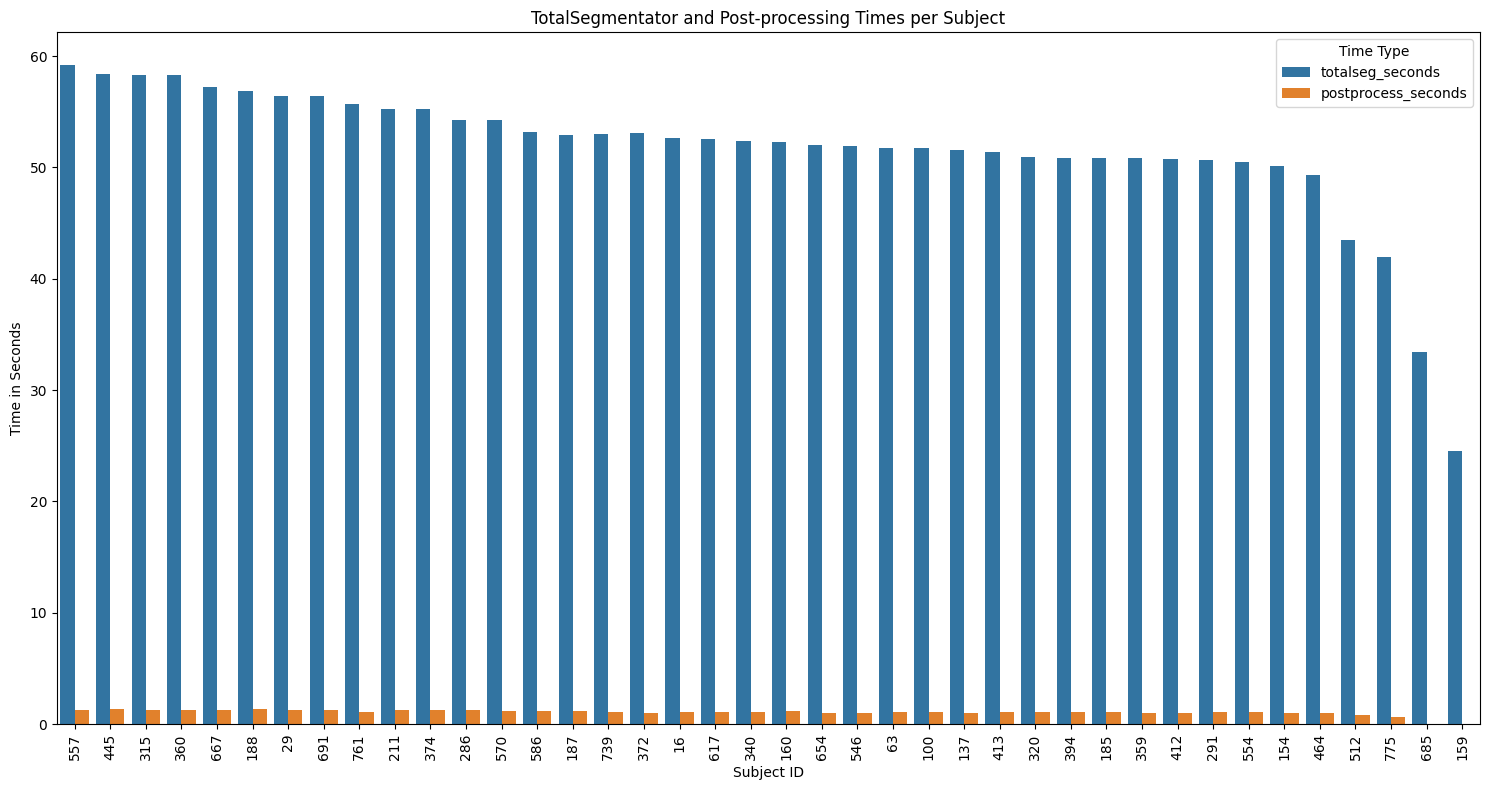

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the manifest file
manifest_path = Path('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/totalseg_heart_manifest.csv')
df_times = pd.read_csv(manifest_path)

# Ensure 'subject_id' is treated as categorical for plotting
df_times['subject_id'] = df_times['subject_id'].astype(str)

# Sort by total_seconds for better visualization if there are many subjects
df_times_sorted = df_times.sort_values(by='total_seconds', ascending=False)

# Prepare data for plotting (long format for seaborn)
df_plot = df_times_sorted[['subject_id', 'totalseg_seconds', 'postprocess_seconds', 'total_seconds']].melt(
    id_vars=['subject_id'],
    var_name='Time Component',
    value_name='Seconds'
)

# Filter out total_seconds if we want to show totalseg_seconds and postprocess_seconds side-by-side
# or keep it if we want to compare all three
df_plot_components = df_plot[df_plot['Time Component'].isin(['totalseg_seconds', 'postprocess_seconds'])]

plt.figure(figsize=(15, 8))
sns.barplot(x='subject_id', y='Seconds', hue='Time Component', data=df_plot_components)
plt.title('TotalSegmentator and Post-processing Times per Subject')
plt.xlabel('Subject ID')
plt.ylabel('Time in Seconds')
plt.xticks(rotation=90)
plt.legend(title='Time Type')
plt.tight_layout()
plt.show()

The bar chart above visualizes the time taken for TotalSegmentator inference (`totalseg_seconds`) and post-processing (`postprocess_seconds`) for each subject.

From this plot, you can observe:
- How much time each step contributes to the overall processing for a given subject.
- Any subjects that took significantly longer than others for either step.
- The general distribution of processing times across the selected subjects.

### Statistical Summary of Processing Times

In [14]:
import pandas as pd
from pathlib import Path

manifest_path = Path('/content/drive/MyDrive/GSoC_PrediCT/outputs/project1/totalseg_heart_manifest.csv')
df_times = pd.read_csv(manifest_path)

# Calculate descriptive statistics for processing times
totalseg_stats = df_times['totalseg_seconds'].describe()
preprocess_stats = df_times['postprocess_seconds'].describe()
total_stats = df_times['total_seconds'].describe()

print('TotalSegmentator Inference Time Statistics (seconds):')
print(totalseg_stats)
print('\nPost-processing Time Statistics (seconds):')
print(preprocess_stats)
print('\nTotal Processing Time Statistics (seconds):')
print(total_stats)

TotalSegmentator Inference Time Statistics (seconds):
count    40.000000
mean     51.652968
std       6.406287
min      24.542909
25%      50.863124
50%      52.331989
75%      55.238425
max      59.167523
Name: totalseg_seconds, dtype: float64

Post-processing Time Statistics (seconds):
count    4.000000e+01
mean     1.061845e+00
std      2.860829e-01
min      8.570000e-07
25%      1.038365e+00
50%      1.076834e+00
75%      1.266260e+00
max      1.368617e+00
Name: postprocess_seconds, dtype: float64

Total Processing Time Statistics (seconds):
count    40.000000
mean     52.714813
std       6.682953
min      24.542910
25%      51.900759
50%      53.460288
75%      56.518878
max      60.465945
Name: total_seconds, dtype: float64


### Subjects with Longest Total Processing Times

In [15]:
# Sort by total_seconds to identify subjects that took significantly longer
df_times_sorted_desc = df_times.sort_values(by='total_seconds', ascending=False)

print('Top 5 Subjects with the Longest Total Processing Times:')
display(df_times_sorted_desc[['subject_id', 'totalseg_seconds', 'postprocess_seconds', 'total_seconds']].head(5))

Top 5 Subjects with the Longest Total Processing Times:


,subject_id,totalseg_seconds,postprocess_seconds,total_seconds
23,557,59.167523,1.298423,60.465945
35,445,58.370328,1.322905,59.693233
38,315,58.299623,1.303003,59.602626
30,360,58.261128,1.264894,59.526023
37,667,57.215486,1.291427,58.506913


### Distribution of Processing Times

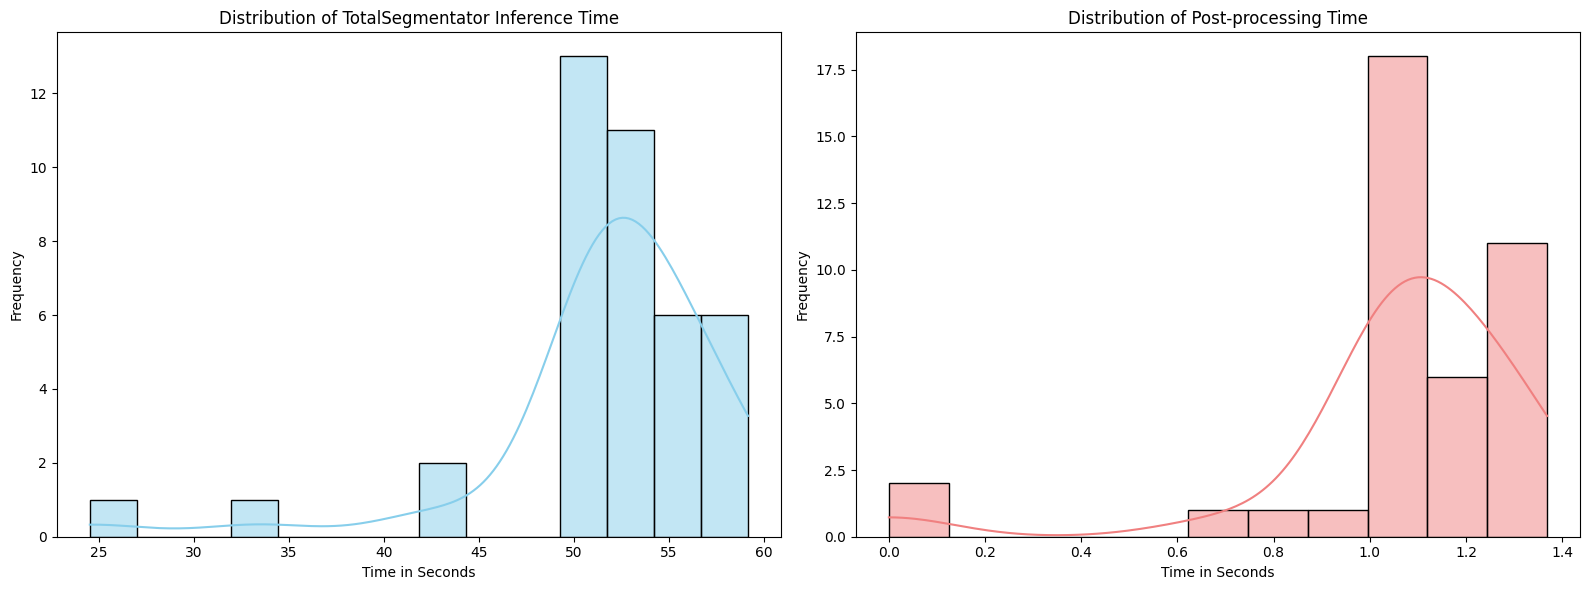

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_times['totalseg_seconds'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of TotalSegmentator Inference Time')
axes[0].set_xlabel('Time in Seconds')
axes[0].set_ylabel('Frequency')

sns.histplot(df_times['postprocess_seconds'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Post-processing Time')
axes[1].set_xlabel('Time in Seconds')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()